In [ ]:
!pip install krippendorff

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
from pathlib import Path
from datasets import Dataset

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/fyp-2025/Datasets/HumanEvaluationFYP2025")

TASK_COLUMNS = [
    "Human-Likeness",
    "Continuity and Context Understanding",
    "Tone and Clarity",
    "Task Appropriateness",
]

MODEL_MAP = {
    "A": "Virtuoso-large",
    "B": "SmolLM3-3B",
    "C": "Gemini-2.5-Flash",
    "D": "Gemma-3-4B",
    "E": "GPT-4.1",
    "F": "Qwen3-4B",
    "G": "Phi-4-Mini",
    "H": "Llama-3.2-Instruct",
}

HF_USERNAME = "Lakshan2003"
DATASET_SUFFIX = "customerservice-Human"

In [ ]:
def load_evaluator_full_data(evaluator_name):
    evaluator_path = BASE_DIR / evaluator_name
    dfs = []

    for file in sorted(evaluator_path.glob("*.xlsx")):
        letter = file.stem
        model = MODEL_MAP.get(letter)

        if model is None:
            raise ValueError(f"Unknown model letter: {letter}")

        df = pd.read_excel(file)

        # DROP columns that are entirely null
        df = df.dropna(axis=1, how="all")

        # Drop rows where all score columns are null (empty rows)
        df = df.dropna(subset=TASK_COLUMNS, how="all")

        if len(df) != 500:
            raise ValueError(
                f"{file.name} has {len(df)} valid rows after cleaning (expected 500)"
            )

        df["Model"] = model
        df["Evaluator"] = evaluator_name

        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [ ]:
eval1_full = load_evaluator_full_data("Evaluator 1")
eval2_full = load_evaluator_full_data("Evaluator 2")
eval3_full = load_evaluator_full_data("Evaluator 3")

In [ ]:
eval1_full.drop(columns=[False], inplace=True)
eval2_full.drop(columns=[False], inplace=True)
eval3_full.drop(columns=[False], inplace=True)

In [ ]:
print(eval1_full.columns.tolist())

['conversation_id', 'conversation_stage', 'instruction', 'history', 'history_summary', 'client_question', 'ground_truth', 'generated_answer', 'Human-Likeness', 'Continuity and Context Understanding', 'Tone and Clarity', 'Task Appropriateness', 'Model', 'Evaluator']


In [ ]:
list(eval1_full.columns)

['conversation_id',
 'conversation_stage',
 'instruction',
 'history',
 'history_summary',
 'client_question',
 'ground_truth',
 'generated_answer',
 'Human-Likeness',
 'Continuity and Context Understanding',
 'Tone and Clarity',
 'Task Appropriateness',
 'Model',
 'Evaluator']

In [ ]:
def push_df_to_hub(df, repo_name, private=False):
    dataset = Dataset.from_pandas(df, preserve_index=False)
    dataset.push_to_hub(
        repo_name,
        private=private
    )

In [ ]:
def push_model_evaluator_splits(df, evaluator_id):
    for model_name in df["Model"].unique():
        model_df = df[df["Model"] == model_name].reset_index(drop=True)

        repo_name = (
            f"{HF_USERNAME}/"
            f"{model_name}-{DATASET_SUFFIX}-evaluator_{evaluator_id}_data"
        )

        print(f"Pushing: {repo_name}")
        push_df_to_hub(model_df, repo_name)

In [ ]:
push_model_evaluator_splits(eval1_full, evaluator_id=1)
push_model_evaluator_splits(eval2_full, evaluator_id=2)
push_model_evaluator_splits(eval3_full, evaluator_id=3)

Pushing: Lakshan2003/Virtuoso-large-customerservice-Human-evaluator_1_data


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########|  579kB /  579kB            

README.md:   0%|          | 0.00/893 [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


In [ ]:
TASK_COLUMNS = [
    "Human-Likeness",
    "Continuity and Context Understanding",
    "Tone and Clarity",
    "Task Appropriateness",
]

def evaluator_results_df(eval_full_df):
    grouped = (
        eval_full_df
        .groupby("Model")[TASK_COLUMNS]
        .mean()
        .round(3)
        .reset_index()
    )

    # overall mean across the 4 criteria
    grouped["Overall_Mean"] = (
        grouped[TASK_COLUMNS].mean(axis=1).round(3)
    )

    # tested conversation count (per model)
    counts = (
        eval_full_df
        .groupby("Model")
        .size()
        .reset_index(name="Tested Conversation Count")
    )

    # merge means + counts
    result = grouped.merge(counts, on="Model")

    # evaluator name (single value, repeated)
    evaluator_name = eval_full_df["Evaluator"].iloc[0]
    result["Evaluator"] = evaluator_name

    return result

In [ ]:
evaluator1_results = evaluator_results_df(eval1_full)
evaluator2_results = evaluator_results_df(eval2_full)
evaluator3_results = evaluator_results_df(eval3_full)

In [ ]:
all_evaluators_results = pd.concat(
    [evaluator1_results, evaluator2_results, evaluator3_results],
    ignore_index=True
)

In [ ]:
assert evaluator1_results.shape[0] == 8
assert evaluator2_results.shape[0] == 8
assert evaluator3_results.shape[0] == 8

assert (evaluator1_results["Tested Conversation Count"] == 500).all()
assert (evaluator2_results["Tested Conversation Count"] == 500).all()
assert (evaluator3_results["Tested Conversation Count"] == 500).all()

#### Evaluator 1 Results

In [ ]:
print("Evaluator 1 Results")
display(evaluator1_results)

Evaluator 1 Results


,Model,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,4.534,4.886,4.674,4.416,4.628,500,Evaluator 1
1,Gemini-2.5-Flash,4.096,4.798,4.296,4.154,4.336,500,Evaluator 1
2,Gemma-3-4B,2.986,2.526,2.872,2.208,2.648,500,Evaluator 1
3,Llama-3.2-Instruct,4.224,4.464,4.334,3.928,4.238,500,Evaluator 1
4,Phi-4-Mini,4.120,4.472,4.228,3.730,4.138,500,Evaluator 1
5,Qwen3-4B,4.166,4.416,4.240,3.722,4.136,500,Evaluator 1
6,SmolLM3-3B,2.796,2.612,2.780,2.372,2.640,500,Evaluator 1
7,Virtuoso-large,4.342,4.842,4.692,4.606,4.620,500,Evaluator 1


#### Evaluator 2 Results

In [ ]:
print("Evaluator 2 Results")
display(evaluator2_results)

Evaluator 2 Results


,Model,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,4.764,4.778,4.764,4.176,4.620,500,Evaluator 2
1,Gemini-2.5-Flash,4.218,4.372,4.208,3.462,4.065,500,Evaluator 2
2,Gemma-3-4B,3.176,2.486,3.040,2.102,2.701,500,Evaluator 2
3,Llama-3.2-Instruct,4.244,4.180,4.236,3.530,4.048,500,Evaluator 2
4,Phi-4-Mini,4.190,4.124,4.206,3.416,3.984,500,Evaluator 2
5,Qwen3-4B,4.220,4.118,4.224,3.458,4.005,500,Evaluator 2
6,SmolLM3-3B,3.122,2.588,3.088,2.156,2.738,500,Evaluator 2
7,Virtuoso-large,4.584,4.630,4.566,3.886,4.416,500,Evaluator 2


#### Evaluator 3 Results

In [ ]:
print("Evaluator 3 Results")
display(evaluator3_results)

Evaluator 3 Results


,Model,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,4.724,4.818,4.728,4.266,4.634,500,Evaluator 3
1,Gemini-2.5-Flash,4.228,4.532,4.238,3.694,4.173,500,Evaluator 3
2,Gemma-3-4B,3.168,2.548,2.992,2.128,2.709,500,Evaluator 3
3,Llama-3.2-Instruct,4.282,4.332,4.288,3.706,4.152,500,Evaluator 3
4,Phi-4-Mini,4.182,4.312,4.210,3.512,4.054,500,Evaluator 3
5,Qwen3-4B,4.222,4.258,4.226,3.556,4.066,500,Evaluator 3
6,SmolLM3-3B,3.092,2.644,3.028,2.256,2.755,500,Evaluator 3
7,Virtuoso-large,4.594,4.706,4.654,4.254,4.552,500,Evaluator 3


#### Overall Evaluator Results

In [ ]:
all_evaluators_results = pd.concat(
    [evaluator1_results, evaluator2_results, evaluator3_results],
    ignore_index=True
)

In [ ]:
final_overall_results = (
    all_evaluators_results
    .groupby("Model")[[
        "Human-Likeness",
        "Continuity and Context Understanding",
        "Tone and Clarity",
        "Task Appropriateness",
        "Overall_Mean",
    ]]
    .mean()
    .round(3)
    .reset_index()
)

final_overall_results["Tested Conversation Count"] = 500

In [ ]:
final_overall_results = final_overall_results.sort_values(
    "Overall_Mean", ascending=False
)

In [ ]:
print("Final Overall Results (Averaged Across All Evaluators)")
final_overall_results

Final Overall Results (Averaged Across All Evaluators)


,Model,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count
0,GPT-4.1,4.674,4.827,4.722,4.286,4.627,500
7,Virtuoso-large,4.507,4.726,4.637,4.249,4.529,500
1,Gemini-2.5-Flash,4.181,4.567,4.247,3.770,4.191,500
3,Llama-3.2-Instruct,4.250,4.325,4.286,3.721,4.146,500
5,Qwen3-4B,4.203,4.264,4.230,3.579,4.069,500
4,Phi-4-Mini,4.164,4.303,4.215,3.553,4.059,500
6,SmolLM3-3B,3.003,2.615,2.965,2.261,2.711,500
2,Gemma-3-4B,3.110,2.520,2.968,2.146,2.686,500


## Conversation Stage wise Results

In [ ]:
HF_USERNAME = "Lakshan2003"
RESULTS_SUFFIX = "customerservice-Human-evaluation-results"

def push_results_df_to_hub(df, repo_name, private=False):
    dataset = Dataset.from_pandas(df, preserve_index=False)
    dataset.push_to_hub(
        repo_name,
        private=private
    )


push_results_df_to_hub(
    evaluator1_results,
    f"{HF_USERNAME}/{RESULTS_SUFFIX}-evaluator_1"
)

push_results_df_to_hub(
    evaluator2_results,
    f"{HF_USERNAME}/{RESULTS_SUFFIX}-evaluator_2"
)

push_results_df_to_hub(
    evaluator3_results,
    f"{HF_USERNAME}/{RESULTS_SUFFIX}-evaluator_3"
)

push_results_df_to_hub(
    final_overall_results,
    f"{HF_USERNAME}/{RESULTS_SUFFIX}-overall"
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 4.38kB / 4.38kB            

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 4.00kB / 4.00kB            

README.md:   0%|          | 0.00/562 [00:00<?, ?B/s]

### Conversation Stage wise results

In [ ]:
STAGE_COL = "conversation_stage"

def evaluator_stage_results_df(eval_full_df):
    grouped = (
        eval_full_df
        .groupby(["Model", STAGE_COL])[TASK_COLUMNS]
        .mean()
        .round(3)
        .reset_index()
    )

    # overall mean across the 4 criteria
    grouped["Overall_Mean"] = (
        grouped[TASK_COLUMNS].mean(axis=1).round(3)
    )

    # tested conversation count per (model, stage)
    counts = (
        eval_full_df
        .groupby(["Model", STAGE_COL])
        .size()
        .reset_index(name="Tested Conversation Count")
    )

    result = grouped.merge(
        counts,
        on=["Model", STAGE_COL]
    )

    # evaluator name
    evaluator_name = eval_full_df["Evaluator"].iloc[0]
    result["Evaluator"] = evaluator_name

    return result

In [ ]:
evaluator1_stage_results = evaluator_stage_results_df(eval1_full)
evaluator2_stage_results = evaluator_stage_results_df(eval2_full)
evaluator3_stage_results = evaluator_stage_results_df(eval3_full)

#### Evaluation stage wise (Evaluator 1)

In [ ]:
evaluator1_stage_results

,Model,conversation_stage,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,BEGINNING,4.280,4.840,4.480,4.140,4.435,50,Evaluator 1
1,GPT-4.1,END,4.720,4.800,4.820,4.620,4.740,50,Evaluator 1
2,GPT-4.1,MIDDLE,4.542,4.902,4.680,4.425,4.637,400,Evaluator 1
3,Gemini-2.5-Flash,BEGINNING,3.960,4.740,4.160,4.240,4.275,50,Evaluator 1
4,Gemini-2.5-Flash,END,4.320,4.760,4.460,4.080,4.405,50,Evaluator 1
5,Gemini-2.5-Flash,MIDDLE,4.085,4.810,4.292,4.152,4.335,400,Evaluator 1
6,Gemma-3-4B,BEGINNING,2.880,2.320,2.780,2.000,2.495,50,Evaluator 1
7,Gemma-3-4B,END,2.820,2.580,2.820,2.400,2.655,50,Evaluator 1
8,Gemma-3-4B,MIDDLE,3.020,2.545,2.890,2.210,2.666,400,Evaluator 1
9,Llama-3.2-Instruct,BEGINNING,4.080,4.280,4.120,3.720,4.050,50,Evaluator 1


#### Evaluation stage wise (Evaluator 2)

In [ ]:
evaluator2_stage_results

,Model,conversation_stage,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,BEGINNING,4.600,4.700,4.600,4.000,4.475,50,Evaluator 2
1,GPT-4.1,END,4.940,4.720,4.920,4.460,4.760,50,Evaluator 2
2,GPT-4.1,MIDDLE,4.762,4.795,4.765,4.162,4.621,400,Evaluator 2
3,Gemini-2.5-Flash,BEGINNING,4.300,4.320,4.280,3.740,4.160,50,Evaluator 2
4,Gemini-2.5-Flash,END,4.340,4.280,4.280,3.820,4.180,50,Evaluator 2
5,Gemini-2.5-Flash,MIDDLE,4.192,4.390,4.190,3.382,4.039,400,Evaluator 2
6,Gemma-3-4B,BEGINNING,3.100,2.300,3.020,1.940,2.590,50,Evaluator 2
7,Gemma-3-4B,END,3.000,2.580,2.740,2.360,2.670,50,Evaluator 2
8,Gemma-3-4B,MIDDLE,3.208,2.498,3.080,2.090,2.719,400,Evaluator 2
9,Llama-3.2-Instruct,BEGINNING,4.100,4.180,4.080,3.440,3.950,50,Evaluator 2


#### Evaluation stage wise (Evaluator 3)

In [ ]:
evaluator3_stage_results

,Model,conversation_stage,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluator
0,GPT-4.1,BEGINNING,4.520,4.720,4.540,4.080,4.465,50,Evaluator 3
1,GPT-4.1,END,4.940,4.740,4.900,4.480,4.765,50,Evaluator 3
2,GPT-4.1,MIDDLE,4.722,4.840,4.730,4.262,4.639,400,Evaluator 3
3,Gemini-2.5-Flash,BEGINNING,4.300,4.520,4.280,3.820,4.230,50,Evaluator 3
4,Gemini-2.5-Flash,END,4.380,4.400,4.360,3.860,4.250,50,Evaluator 3
5,Gemini-2.5-Flash,MIDDLE,4.200,4.550,4.218,3.658,4.156,400,Evaluator 3
6,Gemma-3-4B,BEGINNING,3.060,2.460,2.860,1.920,2.575,50,Evaluator 3
7,Gemma-3-4B,END,3.060,2.620,2.780,2.320,2.695,50,Evaluator 3
8,Gemma-3-4B,MIDDLE,3.195,2.550,3.035,2.130,2.728,400,Evaluator 3
9,Llama-3.2-Instruct,BEGINNING,4.140,4.220,4.080,3.620,4.015,50,Evaluator 3


In [ ]:
all_stage_evaluator_results = pd.concat(
    [
        evaluator1_stage_results,
        evaluator2_stage_results,
        evaluator3_stage_results
    ],
    ignore_index=True
)

In [ ]:
def stage_wise_mean_across_evaluators(stage_eval_df):
    grouped = (
        stage_eval_df
        .groupby(["Model", "conversation_stage"])[
            TASK_COLUMNS + ["Overall_Mean"]
        ]
        .mean()
        .round(3)
        .reset_index()
    )

    # average tested conversation count
    counts = (
        stage_eval_df
        .groupby(["Model", "conversation_stage"])[
            "Tested Conversation Count"
        ]
        .mean()
        .round(0)
        .astype(int)
        .reset_index()
    )

    result = grouped.merge(
        counts,
        on=["Model", "conversation_stage"]
    )

    result["Evaluators_Averaged"] = (
        stage_eval_df["Evaluator"].nunique()
    )

    return result

In [ ]:
final_stagewise_mean_df = stage_wise_mean_across_evaluators(
    all_stage_evaluator_results
)

#### Evaluation stage wise (Final results)

In [ ]:
final_stagewise_mean_df

,Model,conversation_stage,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluators_Averaged
0,GPT-4.1,BEGINNING,4.467,4.753,4.540,4.073,4.458,50,3
1,GPT-4.1,END,4.867,4.753,4.880,4.520,4.755,50,3
2,GPT-4.1,MIDDLE,4.675,4.846,4.725,4.283,4.632,400,3
3,Gemini-2.5-Flash,BEGINNING,4.187,4.527,4.240,3.933,4.222,50,3
4,Gemini-2.5-Flash,END,4.347,4.480,4.367,3.920,4.278,50,3
5,Gemini-2.5-Flash,MIDDLE,4.159,4.583,4.233,3.731,4.177,400,3
6,Gemma-3-4B,BEGINNING,3.013,2.360,2.887,1.953,2.553,50,3
7,Gemma-3-4B,END,2.960,2.593,2.780,2.360,2.673,50,3
8,Gemma-3-4B,MIDDLE,3.141,2.531,3.002,2.143,2.704,400,3
9,Llama-3.2-Instruct,BEGINNING,4.107,4.227,4.093,3.593,4.005,50,3


In [ ]:
final_stagewise_mean_df.sort_values(
    ["conversation_stage", "Overall_Mean"]
)

,Model,conversation_stage,Human-Likeness,Continuity and Context Understanding,Tone and Clarity,Task Appropriateness,Overall_Mean,Tested Conversation Count,Evaluators_Averaged
18,SmolLM3-3B,BEGINNING,2.513,2.173,2.487,1.833,2.252,50,3
6,Gemma-3-4B,BEGINNING,3.013,2.360,2.887,1.953,2.553,50,3
12,Phi-4-Mini,BEGINNING,3.940,4.147,4.000,3.440,3.882,50,3
15,Qwen3-4B,BEGINNING,4.073,4.060,4.093,3.433,3.915,50,3
9,Llama-3.2-Instruct,BEGINNING,4.107,4.227,4.093,3.593,4.005,50,3
3,Gemini-2.5-Flash,BEGINNING,4.187,4.527,4.240,3.933,4.222,50,3
21,Virtuoso-large,BEGINNING,4.353,4.680,4.507,4.100,4.410,50,3
0,GPT-4.1,BEGINNING,4.467,4.753,4.540,4.073,4.458,50,3
19,SmolLM3-3B,END,2.733,2.427,2.693,2.193,2.512,50,3
7,Gemma-3-4B,END,2.960,2.593,2.780,2.360,2.673,50,3


In [ ]:
STAGEWISE_MEAN_REPO = (
    f"{HF_USERNAME}/"
    f"{DATASET_SUFFIX}-stagewise_overall_mean"
)

print(f"Pushing stage-wise overall mean to: {STAGEWISE_MEAN_REPO}")

push_df_to_hub(
    final_stagewise_mean_df,
    STAGEWISE_MEAN_REPO,
    private=False
)

Pushing stage-wise overall mean to: Lakshan2003/customerservice-Human-stagewise_overall_mean


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 5.56kB / 5.56kB            

## Evaluator Agreement Correlation Matrix

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import krippendorff

# Configuration
TASK_COLUMNS = [
    "Human-Likeness",
    "Continuity and Context Understanding",
    "Tone and Clarity",
    "Task Appropriateness",
]

ID_COLS = ["conversation_id", "conversation_stage", "Model"]

# Align evaluators by sample
def align_evaluators(eval1, eval2, eval3):
    e1 = eval1[ID_COLS + TASK_COLUMNS].copy()
    e2 = eval2[ID_COLS + TASK_COLUMNS].copy()
    e3 = eval3[ID_COLS + TASK_COLUMNS].copy()

    e1 = e1.rename(columns={c: f"{c}_E1" for c in TASK_COLUMNS})
    e2 = e2.rename(columns={c: f"{c}_E2" for c in TASK_COLUMNS})
    e3 = e3.rename(columns={c: f"{c}_E3" for c in TASK_COLUMNS})

    merged = (
        e1.merge(e2, on=ID_COLS, how="inner")
          .merge(e3, on=ID_COLS, how="inner")
    )

    return merged

aligned_df = align_evaluators(eval1_full, eval2_full, eval3_full)
print("Aligned samples:", len(aligned_df))

Aligned samples: 4000


In [ ]:
taskwise_results = {}

for task in TASK_COLUMNS:
    task_df = pd.DataFrame({
        "Evaluator 1": aligned_df[f"{task}_E1"],
        "Evaluator 2": aligned_df[f"{task}_E2"],
        "Evaluator 3": aligned_df[f"{task}_E3"],
    }).astype(float)

    # Correlations
    pearson = task_df.corr(method="pearson")
    spearman = task_df.corr(method="spearman")

    # Krippendorff’s alpha (ordinal)
    alpha_data = np.vstack([
        task_df["Evaluator 1"].values,
        task_df["Evaluator 2"].values,
        task_df["Evaluator 3"].values,
    ])

    alpha = krippendorff.alpha(
        alpha_data,
        level_of_measurement="ordinal"
    )

    taskwise_results[task] = {
        "pearson": pearson,
        "spearman": spearman,
        "alpha": alpha,
    }

    print(f"\n{task}")
    print("Pearson correlation:")
    print(pearson.round(3))
    print("Krippendorff’s α (ordinal):", round(alpha, 4))


Human-Likeness
Pearson correlation:
             Evaluator 1  Evaluator 2  Evaluator 3
Evaluator 1        1.000        0.783        0.842
Evaluator 2        0.783        1.000        0.929
Evaluator 3        0.842        0.929        1.000
Krippendorff’s α (ordinal): 0.8131

Continuity and Context Understanding
Pearson correlation:
             Evaluator 1  Evaluator 2  Evaluator 3
Evaluator 1        1.000        0.855        0.898
Evaluator 2        0.855        1.000        0.940
Evaluator 3        0.898        0.940        1.000
Krippendorff’s α (ordinal): 0.8222

Tone and Clarity
Pearson correlation:
             Evaluator 1  Evaluator 2  Evaluator 3
Evaluator 1        1.000        0.815        0.861
Evaluator 2        0.815        1.000        0.927
Evaluator 3        0.861        0.927        1.000
Krippendorff’s α (ordinal): 0.8309

Task Appropriateness
Pearson correlation:
             Evaluator 1  Evaluator 2  Evaluator 3
Evaluator 1        1.000        0.828        0.810
Eva

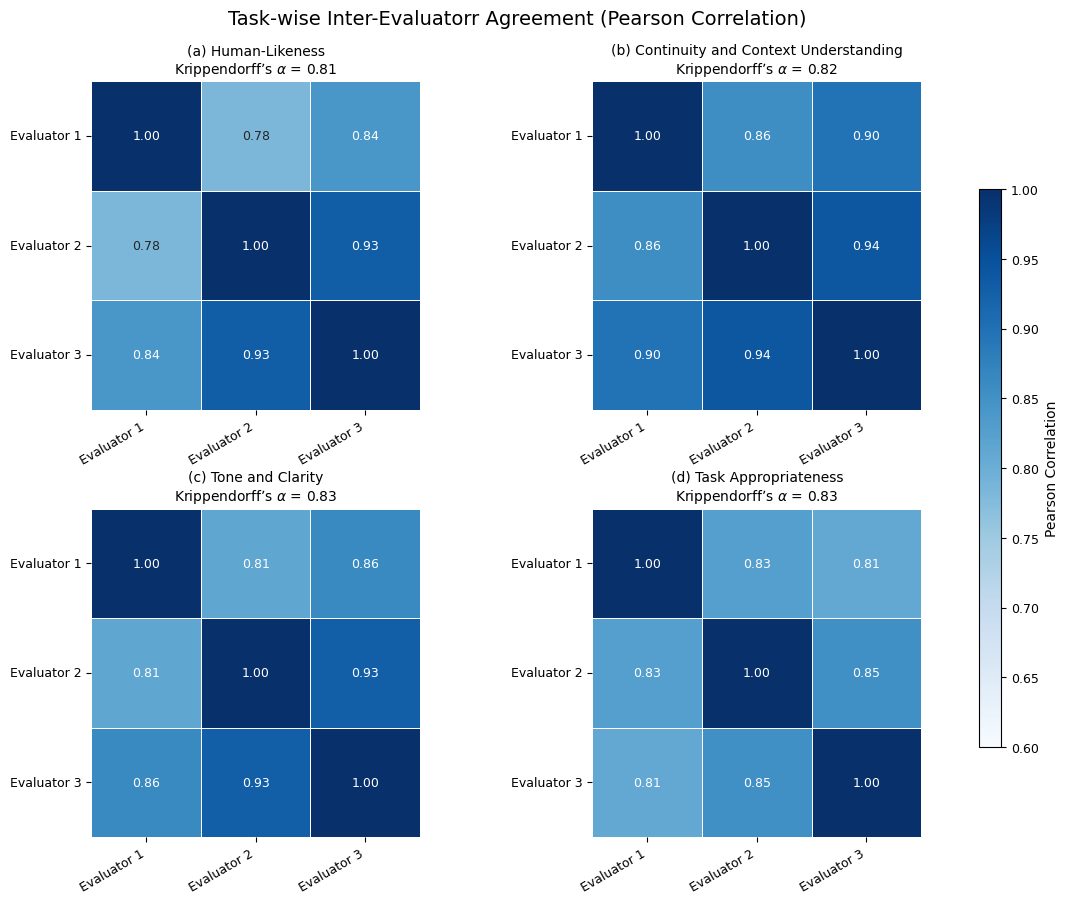

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tasks = list(taskwise_results.keys())
ANNOTATOR_LABELS = ["Evaluator 1", "Evaluator 2", "Evaluator 3"]

# Blue-themed colormap
CMAP = "Blues"
VMIN = 0.6
VMAX = 1.0

# Figure layout (extra vertical space to avoid overlap)
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 9),
    constrained_layout=False
)

axes = axes.flatten()
norm = plt.Normalize(vmin=VMIN, vmax=VMAX)

for idx, (ax, task) in enumerate(zip(axes, tasks)):
    pearson_corr = taskwise_results[task]["pearson"]
    alpha_val = taskwise_results[task]["alpha"]

    sns.heatmap(
        pearson_corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap=CMAP,
        norm=norm,
        square=True,
        linewidths=0.6,
        linecolor="white",
        cbar=False,
        annot_kws={"size": 9}
    )

    # Axis labels (smaller, rotated to avoid overlap)
    ax.set_xticklabels(
        ANNOTATOR_LABELS,
        rotation=30,
        ha="right",
        fontsize=9
    )
    ax.set_yticklabels(
        ANNOTATOR_LABELS,
        rotation=0,
        fontsize=9
    )

    # Subfigure title (separated cleanly)
    ax.set_title(
        f"({chr(97 + idx)}) {task}\nKrippendorff’s $\\alpha$ = {alpha_val:.2f}",
        fontsize=10,
        pad=6
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# Shared colorbar (right side, spaced)
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.62])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Pearson Correlation", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Overall title (higher to avoid collision)
fig.suptitle(
    "Task-wise Inter-Evaluatorr Agreement (Pearson Correlation)",
    fontsize=14,
    y=1
)

# Manual spacing (prevents overlap in LaTeX)
plt.subplots_adjust(
    left=0.08,
    right=0.90,
    top=0.92,
    bottom=0.08,
    hspace=0.30,
    wspace=0.25
)

plt.show()